In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/B_varreduction/pca_variables.csv")
weathercluster_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/weather_7.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")
Static_contr = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/static_contributers.csv")

stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)
GEV_clusters["cluster_id"] = GEV_clusters["cluster"]

label_df = GEV_clusters[["station", "cluster", "cluster_id", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on=["station","lat", "lon"], how="inner")
model_df = model_df.merge(Static_contr, on=["station","lat", "lon", "cluster"], how="inner")

In [4]:

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level","residual","tide","lat","lon","count","missing_frac",
                        "extract_time","name","unnamed", "name", "Unnamed", 'HYRIV' , "gev", "ks", "kuiper", "r2", "dist_to_CVI_m",
                        "dist_to_morpho_m", "H", "id", "ID", "HYR", "GEOM", "POINT")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols
#model_df = model_df.groupby("station").mean(numeric_only=True)
model_df = model_df.reset_index().groupby("station").agg(
    lambda x: x.max() if pd.api.types.is_numeric_dtype(x)
    else x.mode().iloc[0]
)
# Compute cluster sizes
cluster_counts = model_df["cluster_id"].value_counts()

# Keep only stations belonging to clusters with >1 entry
model_df = model_df[model_df["cluster_id"].isin(cluster_counts[cluster_counts > 1].index)]
# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster_id']

Stations for modeling: 277
cluster
3    97
1    78
4    70
6    16
2    16
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler

X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

# one-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# numeric only
X = X.select_dtypes(include="number")

# handle NaNs
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# standardize (MANDATORY for k-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


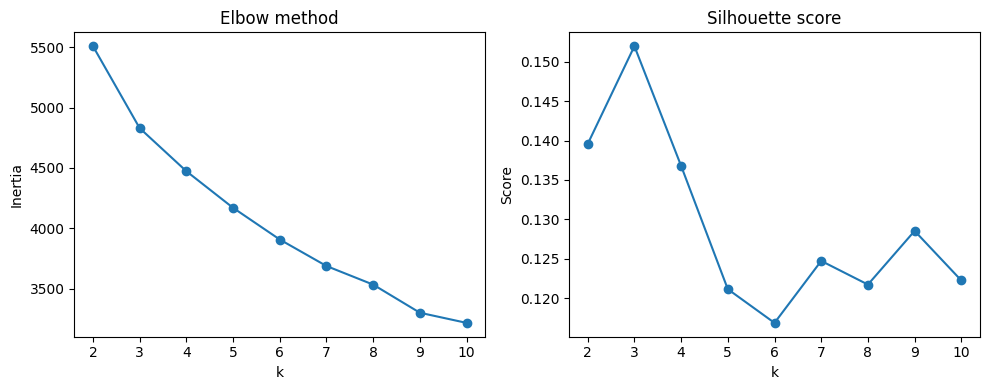

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

ks = range(2, 11)
inertia = []
silhouette = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=0)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(ks, inertia, marker="o")
ax[0].set_title("Elbow method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(ks, silhouette, marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()


In [8]:
k_opt = 9  # ← choose based on plots

kmeans = KMeans(n_clusters=k_opt, n_init=50, random_state=0)
model_df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)


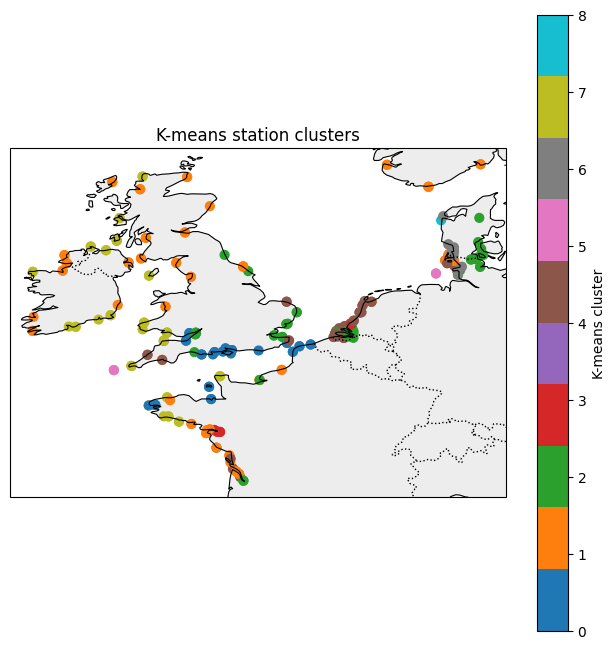

In [9]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor="white")

sc = ax.scatter(
    model_df["lon"],
    model_df["lat"],
    c=model_df["kmeans_cluster"],
    cmap="tab10",
    s=40,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, label="K-means cluster")
ax.set_title("K-means station clusters")
plt.show()


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cluster = model_df["cluster_id"]
df = X.copy()
df["kmeans_cluster"] = cluster.values

# Per-cluster summary
means = df.groupby("kmeans_cluster").mean(numeric_only=True)
stds  = df.groupby("kmeans_cluster").std(numeric_only=True)
counts = df.groupby("kmeans_cluster").size()

# Variation across clusters (on the cluster means)
# Option A: range of means
#var_score = (means.max(axis=0) - means.min(axis=0))

# Option B (often nicer): std of means (between-cluster spread)
var_score = means.std(axis=0)

top_n = 25
top_features = var_score.sort_values(ascending=False).head(top_n).index

means_top = means[top_features]
stds_top  = stds[top_features]


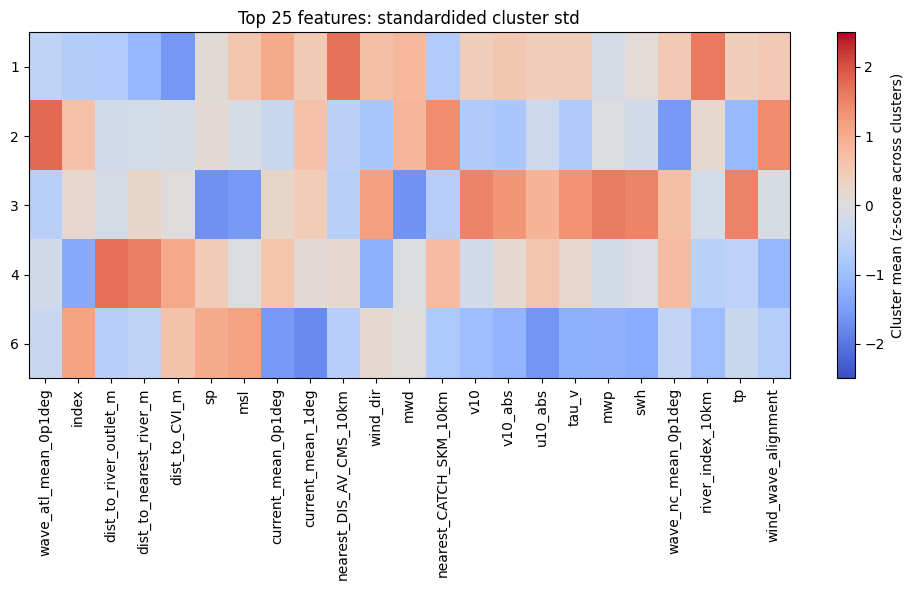

In [20]:
# Z-score across clusters (per feature)
Z = (means_top - means_top.mean(axis=0)) / (means_top.std(axis=0) + 1e-12)

plt.figure(figsize=(10, 6))
plt.imshow(Z, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
plt.colorbar(label="Cluster mean (z-score across clusters)")

plt.yticks(range(len(Z.index)), Z.index)
plt.xticks(range(len(Z.columns)), Z.columns, rotation=90)
plt.title(f"Top {top_n} features: standardided cluster std")
plt.tight_layout()
plt.show()
